### Pacotes importados

In [2]:
using LinearAlgebra
using Plots
default(marker=:circle, linewidth=2, grid=true)

## Chapter 8: Quasi-Newton methods

### Algorithm 8.1: Finite difference Newton's method: one variable

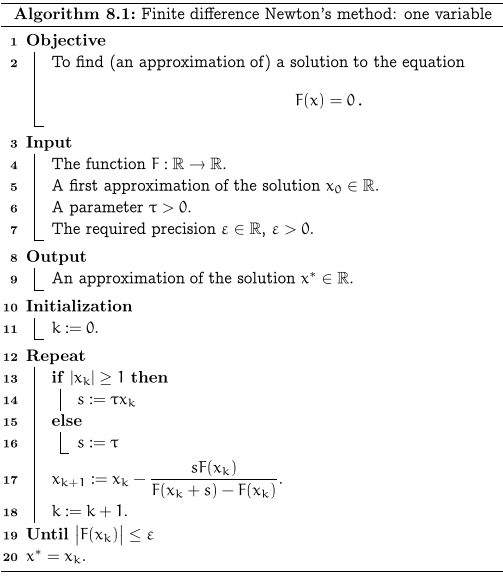

Example: $F(x)=x^2-2$. Run the example with $x_0=2$ and $\tau=10^{-7}$

Convergiu em 4 iterações
Raiz aproximada = 1.414213562374764
F(raiz) = 4.720668300706166e-12


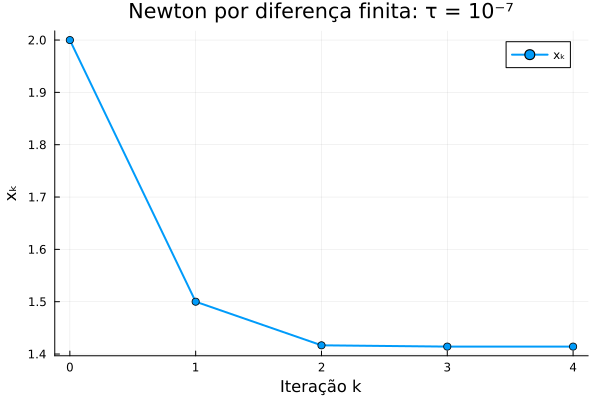

In [3]:

function finite_difference_newton_1var(F, x0, τ; ε=1e-10, maxiter=100)
    x = float(x0)
    hist_x = [x]
    hist_F = [abs(F(x))]

    for k in 1:maxiter
        Fx = F(x)

        if abs(Fx) < ε
            println("Convergiu em ", k-1, " iterações")
            return x, hist_x, hist_F
        end

        
        dF = (F(x + τ) - F(x)) / τ

        if abs(dF) < eps()
            error("Derivada aproximada muito próxima de zero.")
        end

        x = x - Fx/dF
        push!(hist_x, x)
        push!(hist_F, abs(F(x)))
    end

    println("Máximo de iterações atingido")
    return x, hist_x, hist_F
end


F1(x) = x^2 - 2
x0 = 2.0
τ = 1e-7

raiz_τ_pequeno, hist_x_τ_pequeno, hist_F_τ_pequeno = finite_difference_newton_1var(F1, x0, τ)

println("Raiz aproximada = ", raiz_τ_pequeno)
println("F(raiz) = ", F1(raiz_τ_pequeno))

plot(0:length(hist_x_τ_pequeno)-1, hist_x_τ_pequeno,
     xlabel="Iteração k",
     ylabel="xₖ",
     title="Newton por diferença finita: τ = 10⁻⁷",
     label="xₖ")

Run the example with $x_0=2$ and $\tau=0.1$

Convergiu em 8 iterações
Raiz aproximada = 1.4142135623835292
F(raiz) = 2.951239252979576e-11


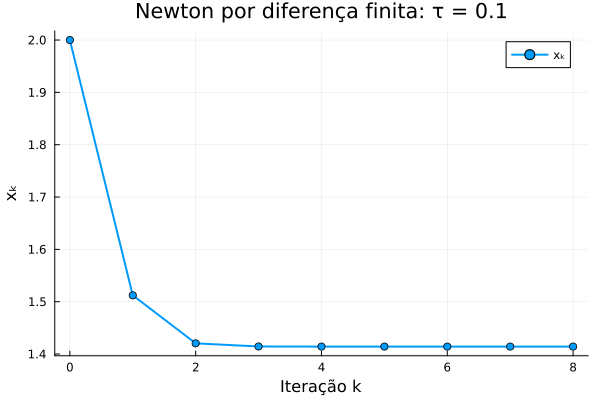

In [4]:
x0 = 2.0
τ = 0.1

raiz_τ_01, hist_x_τ_01, hist_F_τ_01 = finite_difference_newton_1var(F1, x0, τ)

println("Raiz aproximada = ", raiz_τ_01)
println("F(raiz) = ", F1(raiz_τ_01))

plot(0:length(hist_x_τ_01)-1, hist_x_τ_01,
     xlabel="Iteração k",
     ylabel="xₖ",
     title="Newton por diferença finita: τ = 0.1",
     label="xₖ")

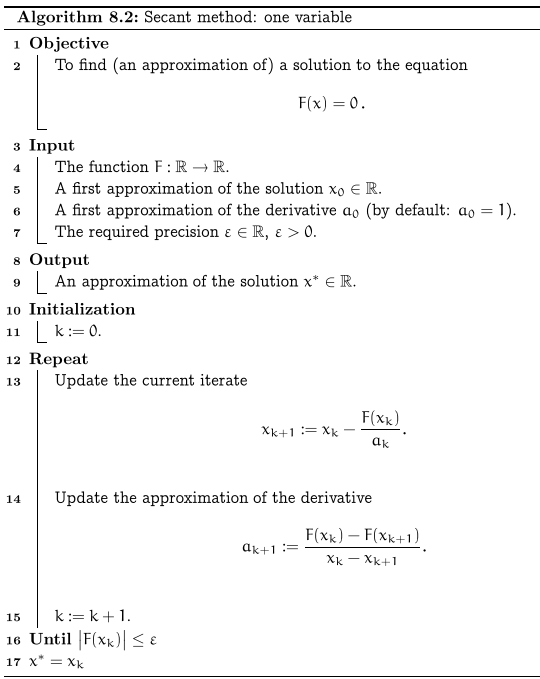

Example: $F(x)=x^2-2$, with $x_0=2$ and $a_0=1$

Convergiu em 7 iterações
Raiz aproximada = 1.4142135623766205
F(raiz) = 9.971579117973306e-12


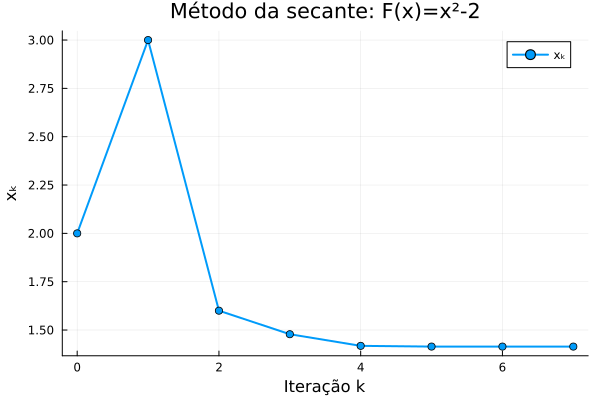

In [5]:
function secant_1var(F, x0, a0; ε=1e-10, maxiter=100)
    x_anterior = float(x0)
    x = float(x0 + a0)

    hist_x = [x_anterior, x]
    hist_F = [abs(F(x_anterior)), abs(F(x))]

    for k in 1:maxiter
        Fx = F(x)
        Fx_anterior = F(x_anterior)

        if abs(Fx) < ε
            println("Convergiu em ", k, " iterações")
            return x, hist_x, hist_F
        end

        denominador = Fx - Fx_anterior
        if abs(denominador) < eps()
            error("Denominador muito próximo de zero no método da secante.")
        end

        x_novo = x - Fx*(x - x_anterior)/denominador

        x_anterior = x
        x = x_novo

        push!(hist_x, x)
        push!(hist_F, abs(F(x)))
    end

    println("Máximo de iterações atingido")
    return x, hist_x, hist_F
end

# Exemplo pedido: F(x) = x² - 2, x0 = 2, a0 = 1
raiz_secante, hist_x_secante, hist_F_secante = secant_1var(F1, 2.0, 1.0)

println("Raiz aproximada = ", raiz_secante)
println("F(raiz) = ", F1(raiz_secante))

plot(0:length(hist_x_secante)-1, hist_x_secante,
     xlabel="Iteração k",
     ylabel="xₖ",
     title="Método da secante: F(x)=x²-2",
     label="xₖ")

### Algorithm 8.3: finite difference Newton's method: $n$ variables

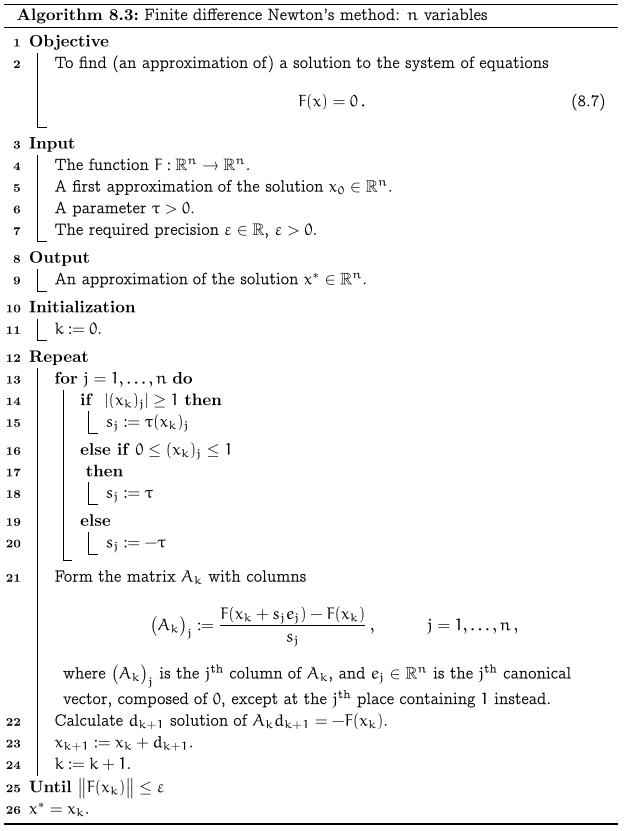

Example: $F(x)=\left(\begin{array}{c}(x_1+1)^2+ x_2^2 - 2 \\ e^{x_1} + x_2^3 - 2 \end{array}\right)$. Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\tau=10^{-7}$

Convergiu em 5 iterações
Solução aproximada = [-5.836914926655613e-12, 1.0000000000111677]
F(solução) = [1.0661693750080303e-11, 2.766631368444905e-11]
Norma de F = 2.9649563681559197e-11


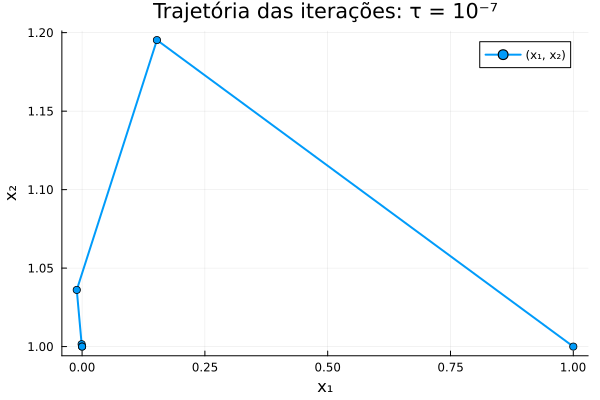

In [6]:
function jacobian_finite_difference(F, x, τ)
    n = length(x)
    Fx = F(x)
    m = length(Fx)
    J = zeros(m, n)

    for j in 1:n
        e = zeros(n)
        e[j] = 1.0
        J[:, j] = (F(x + τ*e) - Fx) / τ
    end

    return J
end

function finite_difference_newton_nvar(F, x0, τ; ε=1e-10, maxiter=100)
    x = float.(copy(x0))
    hist_x = [copy(x)]
    hist_normF = [norm(F(x))]

    for k in 1:maxiter
        Fx = F(x)

        if norm(Fx) < ε
            println("Convergiu em ", k-1, " iterações")
            return x, hist_x, hist_normF
        end

        J = jacobian_finite_difference(F, x, τ)
        Δx = -J \ Fx
        x = x + Δx

        push!(hist_x, copy(x))
        push!(hist_normF, norm(F(x)))
    end

    println("Máximo de iterações atingido")
    return x, hist_x, hist_normF
end


function F2(x)
    x1, x2 = x
    return [
        (x1 + 1)^2 + x2^2 - 2,
        exp(x1) + x2^3 - 2
    ]
end

x0 = [1.0, 1.0]
τ = 1e-7

sol_τ_pequeno, hist_nd_τ_pequeno, hist_norm_τ_pequeno = finite_difference_newton_nvar(F2, x0, τ)

println("Solução aproximada = ", sol_τ_pequeno)
println("F(solução) = ", F2(sol_τ_pequeno))
println("Norma de F = ", norm(F2(sol_τ_pequeno)))

xs = [p[1] for p in hist_nd_τ_pequeno]
ys = [p[2] for p in hist_nd_τ_pequeno]

plot(xs, ys,
     xlabel="x₁",
     ylabel="x₂",
     title="Trajetória das iterações: τ = 10⁻⁷",
     label="(x₁, x₂)")

Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\tau=0.1$

Convergiu em 12 iterações
Solução aproximada = [-3.239547598938408e-11, 1.0000000000324007]
F(solução) = [1.0658141036401503e-14, 6.480682657183934e-11]
Norma de F = 6.480682744825912e-11


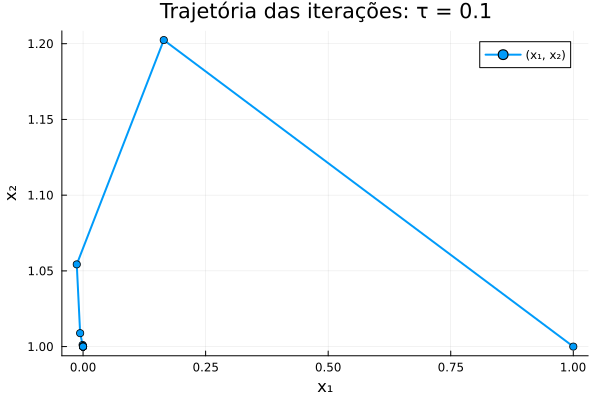

In [7]:
x0 = [1.0, 1.0]
τ = 0.1

sol_τ_01, hist_nd_τ_01, hist_norm_τ_01 = finite_difference_newton_nvar(F2, x0, τ)

println("Solução aproximada = ", sol_τ_01)
println("F(solução) = ", F2(sol_τ_01))
println("Norma de F = ", norm(F2(sol_τ_01)))

xs = [p[1] for p in hist_nd_τ_01]
ys = [p[2] for p in hist_nd_τ_01]

plot(xs, ys,
     xlabel="x₁",
     ylabel="x₂",
     title="Trajetória das iterações: τ = 0.1",
     label="(x₁, x₂)")

### Algorithm 8.4: secant method: $n$ variables

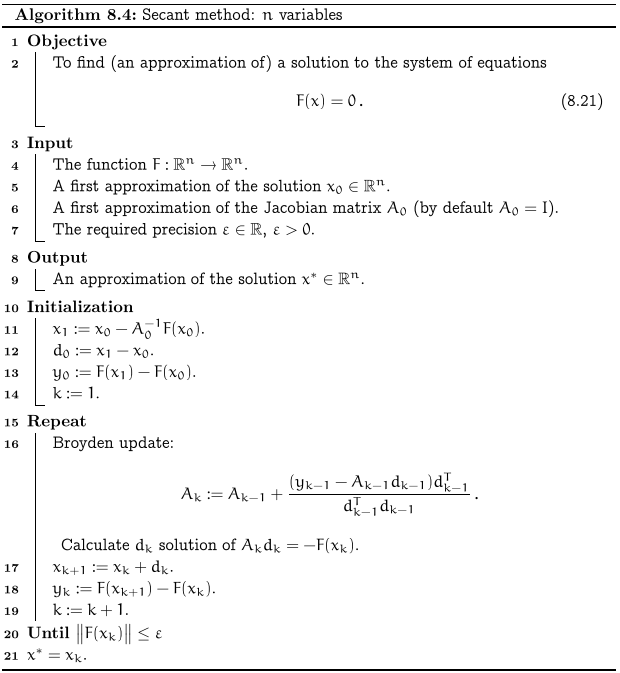

Example 7.11: $F(x)=\left(\begin{array}{c}(x_1+1)^2+ x_2^2 - 2 \\ e^{x_1} + x_2^3 - 2 \end{array}\right)$, $x_0=\left(\begin{array}{c} 1 \\ 1 \end{array}\right)$


Convergiu em 9 iterações
Solução aproximada = [-3.3492629399232045e-14, 1.0000000000000087]
F(solução) = [-4.973799150320701e-14, -7.549516567451064e-15]
Norma de F = 5.0307683301612204e-14


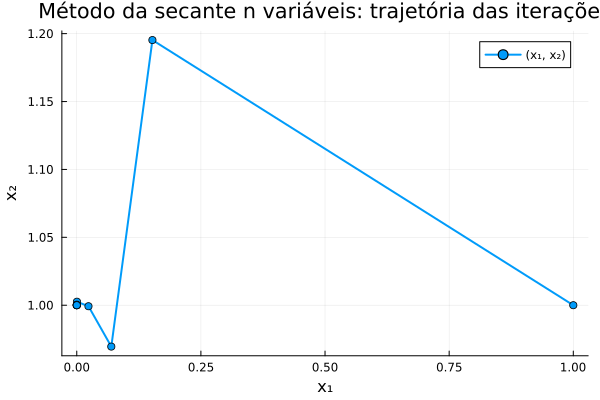

In [8]:
function secant_nvar_broyden(F, x0; ε=1e-10, maxiter=100)
    x = float.(copy(x0))
    n = length(x)

    
    B = jacobian_finite_difference(F, x, 1e-7)

    hist_x = [copy(x)]
    hist_normF = [norm(F(x))]

    for k in 1:maxiter
        Fx = F(x)

        if norm(Fx) < ε
            println("Convergiu em ", k-1, " iterações")
            return x, hist_x, hist_normF
        end

        s = -B \ Fx
        x_novo = x + s

        y = F(x_novo) - Fx

      
        B = B + ((y - B*s) * s') / (s' * s)

        x = x_novo
        push!(hist_x, copy(x))
        push!(hist_normF, norm(F(x)))
    end

    println("Máximo de iterações atingido")
    return x, hist_x, hist_normF
end

x0 = [1.0, 1.0]

sol_secante_nd, hist_secante_nd, hist_norm_secante_nd = secant_nvar_broyden(F2, x0)

println("Solução aproximada = ", sol_secante_nd)
println("F(solução) = ", F2(sol_secante_nd))
println("Norma de F = ", norm(F2(sol_secante_nd)))

xs = [p[1] for p in hist_secante_nd]
ys = [p[2] for p in hist_secante_nd]

plot(xs, ys,
     xlabel="x₁",
     ylabel="x₂",
     title="Método da secante n variáveis: trajetória das iterações",
     label="(x₁, x₂)")